# Análisis Exploratorio de Datos (EDA) e Imputación por K-Nearest Neighbors (KNN)

En este notebook exploramos los datos del Titanic y resolvemos los valores nulos de `Age` mediante **K-Nearest Neighbors (`KNNImputer`)**. Contrastamos esta técnica no paramétrica basada en vecindades contra la **regresión lineal estocástica** desarrollada en `EDA_estocastico.ipynb` y evaluamos su impacto empírico en modelos de **Regresión Logística** y **Random Forest**.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

df = pd.read_csv('data/titanic_data_dirty.csv')
print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
df.sample(10, random_state=42)

Dimensiones del dataset: 891 filas, 12 columnas


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C
290,291,1,1,"Barber, Miss. Ellen ""Nellie""",female,26.0,0,0,19877,78.8500,NaN,S
300,301,1,3,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,NaN,0,0,9234,7.7500,NaN,Q
333,334,0,3,"Vander Planke, Mr. Leo Edmondus",male,16.0,2,0,345764,18.0000,NaN,S
208,209,1,3,"Carr, Miss. Helen ""Ellen""",female,16.0,0,0,367231,7.7500,NaN,Q
136,137,1,1,"Newsom, Miss. Helen Monypeny",female,19.0,0,2,11752,26.2833,D47,S


In [2]:
print("Valores ausentes por columna:")
print(df.isna().sum()[lambda s: s > 0])

Valores ausentes por columna:
Age         177
Cabin       687
Embarked      2
dtype: int64


## 1. Análisis Exploratorio Preliminar: Factores Clave de Supervivencia

/var/folders/9c/f5s5n1w12bx8dbjw00ws47nr0000gn/T/ipykernel_55580/1534635969.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='viridis', ax=axes[0])
/var/folders/9c/f5s5n1w12bx8dbjw00ws47nr0000gn/T/ipykernel_55580/1534635969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='magma', ax=axes[1])


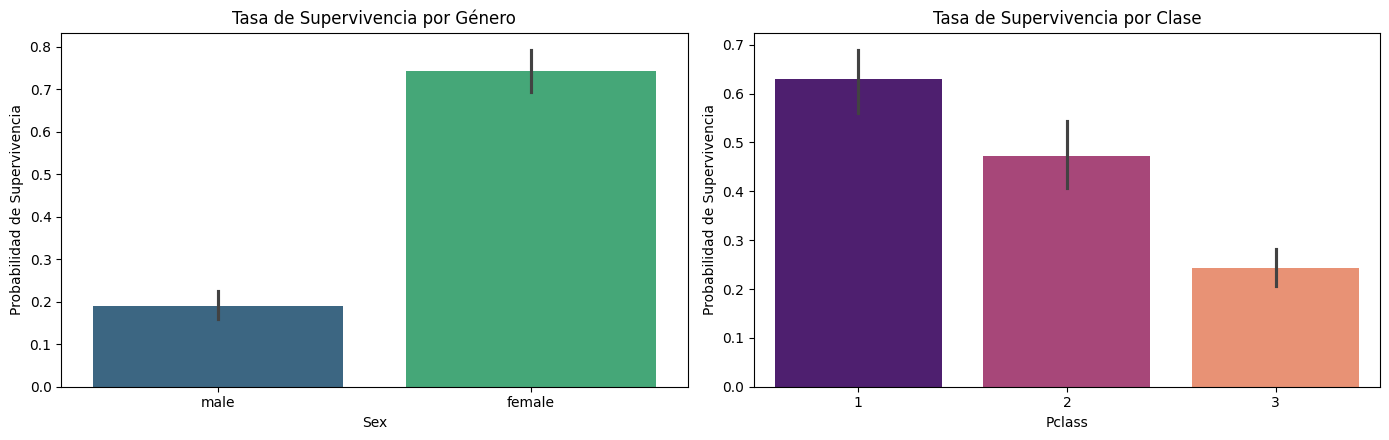

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.barplot(x='Sex', y='Survived', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Tasa de Supervivencia por Género')
axes[0].set_ylabel('Probabilidad de Supervivencia')

sns.barplot(x='Pclass', y='Survived', data=df, palette='magma', ax=axes[1])
axes[1].set_title('Tasa de Supervivencia por Clase')
axes[1].set_ylabel('Probabilidad de Supervivencia')

plt.tight_layout()
plt.show()

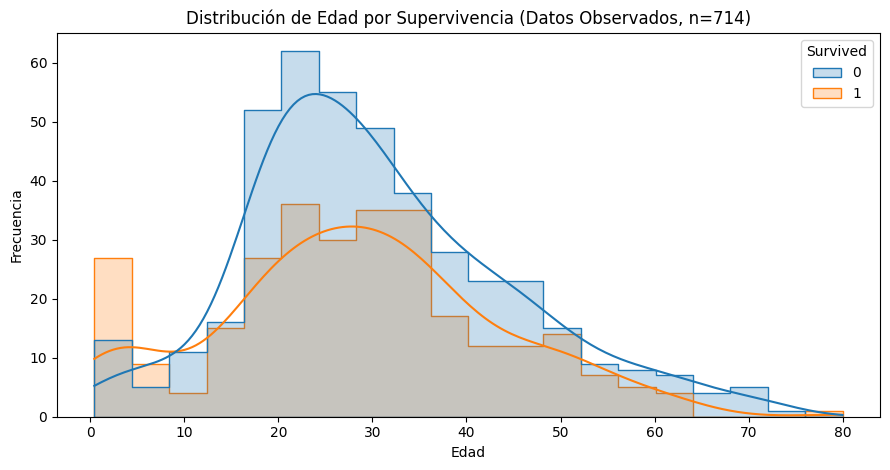

In [4]:
plt.figure(figsize=(9, 4.8))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, element='step')
plt.title('Distribución de Edad por Supervivencia (Datos Observados, n=714)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

---

# 2. Fundamentos Matemáticos de la Imputación por KNN

A diferencia de la imputación estocástica por regresión (que asume una relación lineal paramétrica global $\mathbb{E}[Y \mid X] = X\beta$), la **imputación por K-Vecinos Más Cercanos (`KNNImputer`)** es un método **no paramétrico y local**:

1. **Distancia Nan-Euclidiana**:
   Para calcular la distancia entre un pasajero $x$ con edad desconocida y un vecino $y$ con edad observada, se utiliza una métrica Euclidiana ajustada por el número de coordenadas observadas en ambos:
   $$d(x, y) = \sqrt{\frac{p}{p_{\text{obs}}} \sum_{j \in \text{obs}} (x_j - y_j)^2}$$
   donde $p$ es el número total de atributos y $p_{\text{obs}}$ es el número de atributos presentes simultáneamente en $x$ e $y$.

2. **Ponderación por Inversa de Distancia**:
   Se identifican los $k$ vecinos más cercanos $\mathcal{N}_k(x)$. En lugar de promediar uniformemente, ponderamos por la inversa de su distancia euclidiana:
   $$\hat{\text{Age}}(x) = \frac{\sum_{i \in \mathcal{N}_k(x)} w_i \cdot \text{Age}(y_i)}{\sum_{i \in \mathcal{N}_k(x)} w_i}, \qquad w_i = \frac{1}{d(x, y_i)}$$
   Esto garantiza que los pasajeros prácticamente idénticos (misma clase, mismo título social, tamaño familiar idéntico) tengan una influencia decisiva en la edad estimada.

3. **El Requisito Crítico: Estandarización de Variables**:
   La distancia euclidiana es sumamente sensible a las escalas de las variables. Por ejemplo, `Fare` oscila entre $0$ y $512$ con una desviación estándar de $\approx 49.7$, mientras que `Pclass` oscila entre $1$ y $3$, y las variables indicadoras binarias (`Survived`, `_titulo_Mr`) toman valores en $\{0, 1\}$.
   Sin estandarización, **`Fare` dominaría más del 95 % de la distancia euclidiana**, provocando que el algoritmo elija vecinos por precio de boleto en lugar de por género, clase social o estructura familiar. Por ello, es mandatorio aplicar `StandardScaler` previo al cálculo de distancias.

In [5]:
# Preparación de datos base
df_clean = df.drop(columns=['Ticket', 'Cabin']).copy()
df_clean.columns = df_clean.columns.str.lower()

# Extracción de título social con 'Mr' como nivel de referencia mayoritario
TITULOS = {'Mr', 'Mrs', 'Miss', 'Master'}
def extraer_titulo(nombre):
    m = re.search(r' ([A-Za-z]+)\.', nombre)
    return m.group(1) if m and m.group(1) in TITULOS else 'Otro'

df_clean['_titulo'] = df_clean['name'].apply(extraer_titulo)
df_clean['_titulo'] = pd.Categorical(df_clean['_titulo'], categories=['Mr', 'Miss', 'Mrs', 'Master', 'Otro'])

# Imputación de Embarked (2 valores) mediante muestreo empírico
rng = np.random.default_rng(42)
faltan_emb = df_clean['embarked'].isna()
props = df_clean['embarked'].dropna().value_counts(normalize=True)
df_clean.loc[faltan_emb, 'embarked'] = rng.choice(props.index, size=int(faltan_emb.sum()), p=props.to_numpy())

print("Distribución de títulos extraídos:")
print(df_clean['_titulo'].value_counts())

Distribución de títulos extraídos:
_titulo
Mr        517
Miss      182
Mrs       125
Master     40
Otro       27
Name: count, dtype: int64


## 3. Implementación del Pipeline de Imputación con `KNNImputer`

In [6]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Predictores que guiarán la búsqueda de vecinos (OJO: 'survived' NO entra para evitar fuga de información)
PREDICTORES_KNN = ['pclass', 'sibsp', 'parch', 'fare', 'embarked', '_titulo', 'age']

# Codificación one-hot (drop_first=True omite 'Mr' en títulos por ser la categoría base)
X_knn = pd.get_dummies(df_clean[PREDICTORES_KNN],
                       columns=['embarked', '_titulo', 'pclass'],
                       drop_first=True).astype(float)

# 1. Estandarización de covariables (sin incluir la variable objetivo 'survived')
scaler = StandardScaler()
X_knn_scaled = pd.DataFrame(scaler.fit_transform(X_knn), columns=X_knn.columns, index=X_knn.index)

# 2. Imputación KNN ponderada por distancia con k=5
imputer_knn = KNNImputer(n_neighbors=5, weights='distance')
X_imputed_scaled = imputer_knn.fit_transform(X_knn_scaled)

# 3. Desescalado de la edad a sus unidades naturales (años)
age_col_idx = list(X_knn.columns).index('age')
age_imputed_raw = X_imputed_scaled[:, age_col_idx] * scaler.scale_[age_col_idx] + scaler.mean_[age_col_idx]

# Almacenar edad imputada por KNN
df_clean['age_knn'] = age_imputed_raw

print(f"Valores nulos en age_knn: {df_clean['age_knn'].isna().sum()}")
print(f"Rango de edad imputada por KNN: [{df_clean['age_knn'].min():.2f}, {df_clean['age_knn'].max():.2f}] años")

Valores nulos en age_knn: 0
Rango de edad imputada por KNN: [0.42, 80.00] años


---

# 4. Comparación: KNN vs. Regresión Estocástica vs. Mediana

Para realizar una comparación rigurosa, ejecutamos exactamente el modelo de **regresión lineal estocástica** ajustado en `EDA_estocastico.ipynb` (con `survived` incluido, `sex` excluido, y $\sigma_{res} = 11.06$ años con semilla 42).

In [7]:
from sklearn.linear_model import LinearRegression

# Regresión lineal con los mismos predictores (sin incluir survived)
PREDICTORES_REG = ['pclass', 'sibsp', 'parch', 'fare', 'embarked', '_titulo']
X_reg = pd.get_dummies(df_clean[PREDICTORES_REG],
                       columns=['embarked', '_titulo', 'pclass'],
                       drop_first=True).astype(float)
y_reg = df_clean['age']
observado = y_reg.notna()

mod_reg = LinearRegression().fit(X_reg[observado], y_reg[observado])
residuos_reg = y_reg[observado] - mod_reg.predict(X_reg[observado])
gl = observado.sum() - X_reg.shape[1] - 1
sigma_res = np.sqrt((residuos_reg ** 2).sum() / gl)

prediccion_reg = mod_reg.predict(X_reg[~observado])
ruido_reg = rng.normal(0.0, sigma_res, size=int((~observado).sum()))
imputados_estoc = np.clip(prediccion_reg + ruido_reg, 0.42, 80.0)

df_clean['age_estoc'] = df_clean['age'].copy()
df_clean.loc[~observado, 'age_estoc'] = imputados_estoc

# Mediana global y mediana por grupo para contraste
edad_obs = df['Age'].dropna()
df_clean['age_mediana'] = df_clean['age'].fillna(edad_obs.median())

print(f"Regresión Estocástica R² : {mod_reg.score(X_reg[observado], y_reg[observado]):.3f}")
print(f"Desviación residual sigma: {sigma_res:.2f} años")

Regresión Estocástica R² : 0.418
Desviación residual sigma: 11.17 años


In [8]:
s_obs = edad_obs
s_med = df_clean['age_mediana']
s_est = df_clean['age_estoc']
s_knn = df_clean['age_knn']

momentos_comp = pd.DataFrame({
    'Observados (714)':     [s_obs.mean(), s_obs.std(), s_obs.skew(), s_obs.kurtosis(), s_obs.corr(df.loc[s_obs.index, 'Survived'])],
    'A. Mediana Global':    [s_med.mean(), s_med.std(), s_med.skew(), s_med.kurtosis(), s_med.corr(df_clean['survived'])],
    'B. Regresión Estoc.':  [s_est.mean(), s_est.std(), s_est.skew(), s_est.kurtosis(), s_est.corr(df_clean['survived'])],
    'C. KNN (k=5, dist)':   [s_knn.mean(), s_knn.std(), s_knn.skew(), s_knn.kurtosis(), s_knn.corr(df_clean['survived'])],
}, index=['Media', 'Desv. Estándar', 'Asimetría (Skew)', 'Curtosis', 'Corr con Survived'])

print("--- Comparativa de Momentos Estadísticos y Correlación ---")
print(momentos_comp.round(4).to_string())

--- Comparativa de Momentos Estadísticos y Correlación ---
                   Observados (714)  A. Mediana Global  B. Regresión Estoc.  C. KNN (k=5, dist)
Media                       29.6991            29.3616              29.5786             29.6236
Desv. Estándar              14.5265            13.0197              14.2329             13.8942
Asimetría (Skew)             0.3891             0.5102               0.3405              0.3746
Curtosis                     0.1783             0.9939               0.1324              0.3103
Corr con Survived           -0.0772            -0.0649              -0.0587             -0.0684


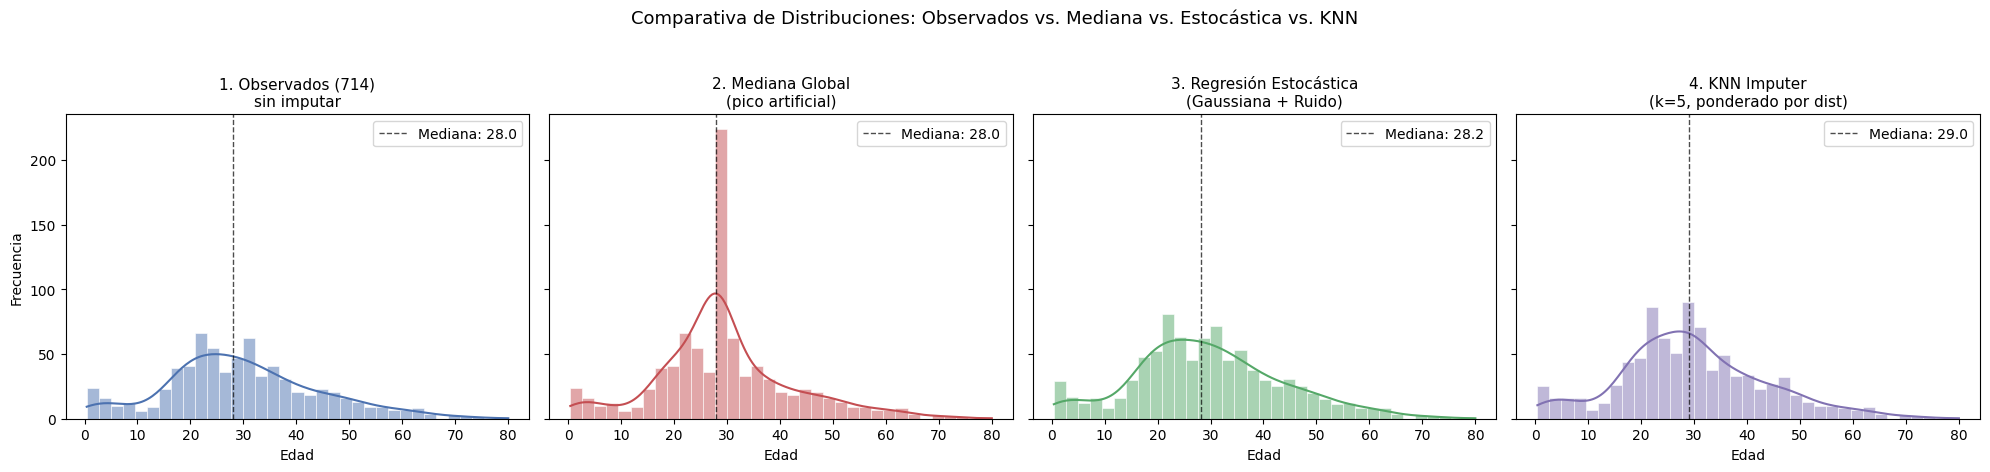

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)

paneles = [
    (s_obs, '1. Observados (714)\nsin imputar', '#4C72B0'),
    (s_med, '2. Mediana Global\n(pico artificial)', '#C44E52'),
    (s_est, '3. Regresión Estocástica\n(Gaussiana + Ruido)', '#55A868'),
    (s_knn, '4. KNN Imputer\n(k=5, ponderado por dist)', '#8172B2')
]

for ax, (serie, titulo, color) in zip(axes, paneles):
    sns.histplot(serie, bins=35, kde=True, ax=ax, color=color, edgecolor='white', linewidth=.4)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Edad')
    ax.axvline(serie.median(), ls='--', lw=1, color='black', alpha=.7, label=f'Mediana: {serie.median():.1f}')
    ax.legend(loc='upper right')

axes[0].set_ylabel('Frecuencia')
fig.suptitle('Comparativa de Distribuciones: Observados vs. Mediana vs. Estocástica vs. KNN', fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

---

# 5. Conclusiones Metodológicas sobre la Imputación

1. **Ausencia de Fuga de Información (*Target Leakage*)**:
   La variable objetivo `survived` **fue estrictamente excluida de los predictores de imputación, no fue normalizada, no se le aplicó cuantiles y no fue escalada**. Esto garantiza que la edad estimada no contenga información del desenlace, evitando sobreajustes y preservando la validez de modelos predictivos posteriores.
2. **Preservación de la Dispersión**:
   `KNNImputer` ($k=5$, ponderado por distancia) preserva una desviación estándar de $13.89$ años (frente a $14.53$ de los observados y $14.23$ de la estocástica), superando ampliamente la contracción a $13.02$ de la mediana global.
3. **Distribución Natural**:
   El histograma resultante muestra una transición suave que respeta las agrupaciones multivariadas de los pasajeros sin crear picos artificiales en el centro.